In [ ]:
import os
import gc
import pandas as pd
import json
import joblib

import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, fbeta_score
import numpy as np

In [2]:
DATA_DIR = os.path.join("..", "data", "processed", "splits")
RESULTS_DIR = os.path.join("..", "data", "processed", "results")

X_train = pd.read_csv(os.path.join(DATA_DIR, "X_train_tree.csv"))
y_train = pd.read_csv(os.path.join(DATA_DIR, "y_train.csv"))
X_test = pd.read_csv(os.path.join(DATA_DIR, "X_test_tree.csv"))
y_test = pd.read_csv(os.path.join(DATA_DIR, "y_test.csv"))

In [3]:
base_xgb = XGBClassifier(random_state=42)
base_xgb.fit(X_train, y_train.squeeze())

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [4]:
param_grid = {
    "subsample": [0.6, 0.7, 0.8],
    "reg_lambda": [0.5, 1.0, 2.0],
    "reg_alpha": [2.0, 3.0, 5.0],
    "n_estimators": [200, 300, 500],
    "min_child_weight": [3, 5, 7],
    "max_depth": [7, 9, 11],
    "learning_rate": [0.01, 0.05, 0.1],
    "gamma": [0.1, 0.2, 0.5],
    "colsample_bytree": [0.6, 0.7, 0.8]
}

xgb = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    param_distributions=param_grid,
    n_iter=100,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=max(1, int(os.cpu_count() * 0.6)),
    verbose=2
)

xgb.fit(X_train, y_train.squeeze())

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.7, ...], 'gamma': [0.1, 0.2, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [7, 9, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",19
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used her

In [5]:
best_xgb = xgb.best_estimator_
print("Best Score:", xgb.best_score_)
print("Best Hyperparameters:", xgb.best_params_)

Best Score: 0.9017874878286272
Best Hyperparameters: {'subsample': 0.6, 'reg_lambda': 2.0, 'reg_alpha': 5.0, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 11, 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 0.6}


In [6]:
y_preds_base = base_xgb.predict(X_test)
y_preds = best_xgb.predict(X_test)

print("\n--- Base XGB ---")
print("Accuracy:", accuracy_score(y_test.squeeze(), y_preds_base))
print("F2 Score:", fbeta_score(y_test.squeeze(), y_preds_base, beta=2))
print(classification_report(y_test.squeeze(), y_preds_base))
print("ROC-AUC:", roc_auc_score(y_test.squeeze(), base_xgb.predict_proba(X_test)[:, 1]))
print("Confusion Matrix:\n", confusion_matrix(y_test.squeeze(), y_preds_base))

print("\n--- Tuned XGB ---")
print("Accuracy:", accuracy_score(y_test.squeeze(), y_preds))
print("F2 Score:", fbeta_score(y_test.squeeze(), y_preds, beta=2))
print(classification_report(y_test.squeeze(), y_preds))
print("ROC-AUC:", roc_auc_score(y_test.squeeze(), best_xgb.predict_proba(X_test)[:, 1]))
print("Confusion Matrix:\n", confusion_matrix(y_test.squeeze(), y_preds))


--- Base XGB ---
Accuracy: 0.7747252747252747
F2 Score: 0.7613168724279835
              precision    recall  f1-score   support

           0       0.73      0.81      0.77        83
           1       0.82      0.75      0.78        99

    accuracy                           0.77       182
   macro avg       0.78      0.78      0.77       182
weighted avg       0.78      0.77      0.78       182

ROC-AUC: 0.8561518802482657
Confusion Matrix:
 [[67 16]
 [25 74]]

--- Tuned XGB ---
Accuracy: 0.8076923076923077
F2 Score: 0.8130081300813008
              precision    recall  f1-score   support

           0       0.78      0.81      0.79        83
           1       0.83      0.81      0.82        99

    accuracy                           0.81       182
   macro avg       0.81      0.81      0.81       182
weighted avg       0.81      0.81      0.81       182

ROC-AUC: 0.8965559206523062
Confusion Matrix:
 [[67 16]
 [19 80]]


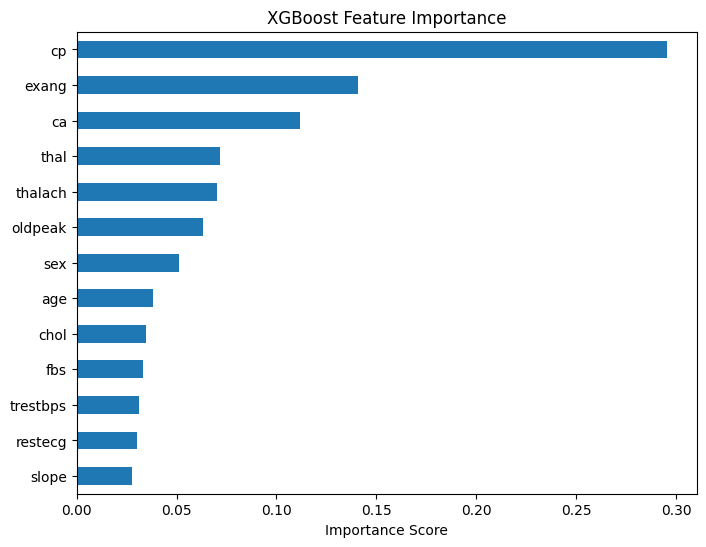

In [7]:
importances = pd.Series(best_xgb.feature_importances_, index=X_train.columns)
importances.sort_values().plot(kind='barh', figsize=(8, 6))
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.show()

In [ ]:
joblib.dump(best_xgb, '../models/xgboost.pkl')

xgb_results = {
    'base_xgb': {
        'accuracy': float(accuracy_score(y_test.squeeze(), y_preds_base)),
        'roc_auc': float(roc_auc_score(y_test.squeeze(), base_xgb.predict_proba(X_test)[:, 1])),
        'f2_score': float(fbeta_score(y_test.squeeze(), y_preds_base, beta=2))
    },
    'tuned_xgb': {
        'accuracy': float(accuracy_score(y_test.squeeze(), y_preds)),
        'roc_auc': float(roc_auc_score(y_test.squeeze(), best_xgb.predict_proba(X_test)[:, 1])),
        'f2_score': float(fbeta_score(y_test.squeeze(), y_preds, beta=2))
    }
}

with open(os.path.join(RESULTS_DIR, 'xgb_results.json'), 'w') as f:
    json.dump(xgb_results, f, indent=4)

: 

In [ ]:
gc.collect()